<a href="https://colab.research.google.com/github/AmatHub21/codingan_kelompok_mechineLearning/blob/main/Code_MLMendiagnosaDenganMenggunkanDatasetKelompok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels

In [3]:
# ============================================================
# SOURCE 1: PERSIAPAN LINGKUNGAN DAN PEMUATAN DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import KNNImputer

from statsmodels.stats.outliers_influence import variance_inflation_factor

from google.colab import files
import io
import warnings

warnings.filterwarnings("ignore")

# Upload dataset CSV
uploaded = files.upload()

# Membaca file CSV
nama_file = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[nama_file]), sep=None, engine="python")

# Menampilkan informasi dataset
print("Ukuran Dataset:", df.shape)

print("\nNama Kolom:")
print(df.columns.tolist())

print("\nLima Data Pertama:")
display(df.head())

print("\nInformasi Dataset:")
df.info()

Saving student-por[1].csv to student-por[1].csv
Ukuran Dataset: (649, 33)

Nama Kolom:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Lima Data Pertama:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    ob

Distribusi Target:
target
1    549
0    100
Name: count, dtype: int64

Persentase Target:
target
1    84.59168
0    15.40832
Name: proportion, dtype: float64


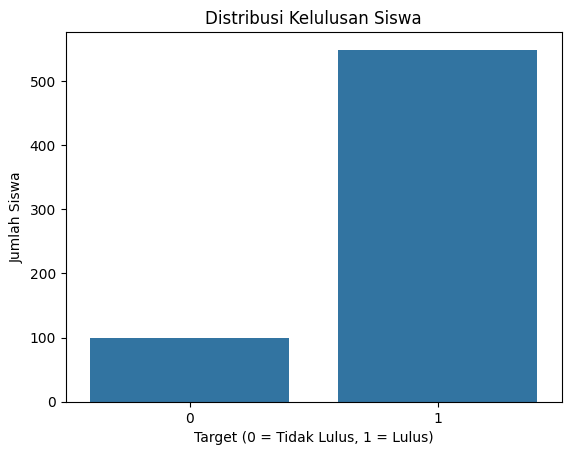

In [7]:
# ============================================================
# SOURCE 2: PEMBENTUKAN TARGET KLASIFIKASI
# ============================================================

# Memastikan kolom G3 tersedia
assert "G3" in df.columns, "Kolom G3 tidak ditemukan!"

# Membuat target:
# 0 = Tidak Lulus
# 1 = Lulus

df["target"] = (df["G3"] >= 10).astype(int)

print("Distribusi Target:")
print(df["target"].value_counts())

print("\nPersentase Target:")
print(df["target"].value_counts(normalize=True) * 100)

# Visualisasi distribusi target
sns.countplot(data=df, x="target")

plt.title("Distribusi Kelulusan Siswa")
plt.xlabel("Target (0 = Tidak Lulus, 1 = Lulus)")
plt.ylabel("Jumlah Siswa")
plt.show()

In [6]:
# ============================================================
# MASALAH 1: DATA LEAKAGE
# ============================================================

# Define 'target' based on 'G3' (e.g., G3 >= 10 for pass/fail)
# Assuming G3 is a score and target is a binary outcome (e.g., pass/fail)
# Let's say a G3 score of 10 or more is considered 'pass' (1), otherwise 'fail' (0)
df['target'] = (df['G3'] >= 10).astype(int)

X = df.drop(columns=["target", "G3"])
y = df["target"]

# Memisahkan fitur numerik dan kategorikal
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# Mengubah fitur kategorikal menjadi angka
X_encoded = pd.get_dummies(X, drop_first=True)

# ============================================================
# SEBELUM MITIGASI: SCALING SEBELUM SPLIT
# ============================================================

X_encoded = X_encoded.fillna(X_encoded.median())

scaler_bocor = StandardScaler()

X_bocor = scaler_bocor.fit_transform(X_encoded)

X_tr_l, X_ts_l, y_tr_l, y_ts_l = train_test_split(
    X_bocor,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_bocor = LogisticRegression(max_iter=2000)

model_bocor.fit(X_tr_l, y_tr_l)

acc_sebelum = model_bocor.score(X_ts_l, y_ts_l)

# ============================================================
# SESUDAH MITIGASI: PIPELINE
# ============================================================

X_tr, X_ts, y_tr, y_ts = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

pipeline_benar = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

pipeline_benar.fit(X_tr, y_tr)

acc_sesudah = pipeline_benar.score(X_ts, y_ts)

print("=== DATA LEAKAGE ===")
print(f"Akurasi Sebelum Mitigasi: {acc_sebelum:.4f}")
print(f"Akurasi Sesudah Mitigasi: {acc_sesudah:.4f}")

=== DATA LEAKAGE ===
Akurasi Sebelum Mitigasi: 0.9077
Akurasi Sesudah Mitigasi: 0.9077


Skewness Awal: 2.0207

=== SKEWED DATA ===
Skewness Sebelum: 2.0207
Skewness Sesudah: 0.1811


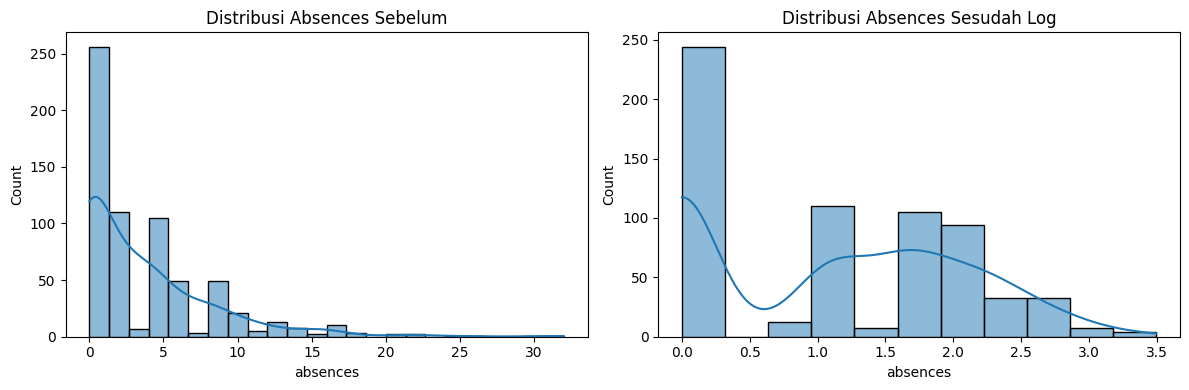

In [8]:
# ============================================================
# MASALAH 2: SKEWED DATA
# ============================================================

fitur = "absences"

# Menghitung skewness awal
skew_awal = df[fitur].skew()

print("Skewness Awal:", round(skew_awal, 4))

# ============================================================
# SEBELUM MITIGASI: STANDARDSCALER
# ============================================================

scaler_std = StandardScaler()

abs_std = scaler_std.fit_transform(df[[fitur]])

skew_sebelum = pd.Series(
    abs_std.flatten()
).skew()

# ============================================================
# SESUDAH MITIGASI: LOG TRANSFORMATION
# ============================================================

abs_log = np.log1p(df[fitur])

scaler_robust = RobustScaler()

abs_robust = scaler_robust.fit_transform(
    abs_log.to_frame()
)

skew_sesudah = abs_log.skew()

print("\n=== SKEWED DATA ===")
print(f"Skewness Sebelum: {skew_sebelum:.4f}")
print(f"Skewness Sesudah: {skew_sesudah:.4f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[fitur], kde=True, ax=axes[0])
axes[0].set_title("Distribusi Absences Sebelum")

sns.histplot(abs_log, kde=True, ax=axes[1])
axes[1].set_title("Distribusi Absences Sesudah Log")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# MASALAH 3: MISSING VALUE
# ============================================================

print("Missing Value Awal:")
print(df.isnull().sum())

# Membuat simulasi missing value
df_missing = df.copy()

# Menyimpan indeks untuk simulasi
np.random.seed(42)

indeks_missing = np.random.choice(
    df_missing.index,
    size=int(0.05 * len(df_missing)),
    replace=False
)

df_missing.loc[indeks_missing, "health"] = np.nan

# ============================================================
# SEBELUM MITIGASI: DROPNA
# ============================================================

df_dropped = df_missing.dropna()

rasio_asli = df_missing["target"].mean()

rasio_dropped = df_dropped["target"].mean()

# ============================================================
# SESUDAH MITIGASI: IMPUTASI
# ============================================================

df_imputed = df_missing.copy()

df_imputed["health_is_missing"] = (
    df_imputed["health"].isna().astype(int)
)

imputer = KNNImputer(n_neighbors=5)

df_imputed[["health"]] = imputer.fit_transform(
    df_imputed[["health", "age", "absences"]]
)[:, [0]]

print("\n=== MISSING VALUE ===")

print("Jumlah Data Awal:", len(df_missing))
print("Jumlah Setelah Dropna:", len(df_dropped))
print("Jumlah Setelah Imputasi:", len(df_imputed))

print("Perubahan Rasio Target Setelah Dropna:",
      round(rasio_dropped - rasio_asli, 4))

Missing Value Awal:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
target        0
dtype: int64

=== MISSING VALUE ===
Jumlah Data Awal: 649
Jumlah Setelah Dropna: 617
Jumlah Setelah Imputasi: 649
Perubahan Rasio Target Setelah Dropna: -0.0015


In [10]:
# ============================================================
# MASALAH 4: MULTIKOLINEARITAS
# ============================================================

fitur_num = [
    "age",
    "Medu",
    "Fedu",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2"
]

X_vif = df[fitur_num].dropna().copy()

# ============================================================
# FUNGSI HITUNG VIF
# ============================================================

def kalkulasi_vif(data):
    return pd.DataFrame({
        "Fitur": data.columns,
        "VIF": [
            variance_inflation_factor(data.values, i)
            for i in range(data.shape[1])
        ]
    })

# ============================================================
# SEBELUM MITIGASI
# ============================================================

vif_sebelum = kalkulasi_vif(X_vif)

# ============================================================
# SESUDAH MITIGASI: MENGHILANGKAN FITUR REDUNDAN
# ============================================================

X_vif_sesudah = X_vif.drop(
    columns=["G2"]
)

vif_sesudah = kalkulasi_vif(X_vif_sesudah)

print("=== VIF SEBELUM MITIGASI ===")
display(vif_sebelum)

print("\n=== VIF SESUDAH MITIGASI ===")
display(vif_sesudah)

=== VIF SEBELUM MITIGASI ===


,Fitur,VIF
0,age,1.189946
1,Medu,1.783253
2,Fedu,1.767469
3,studytime,1.128319
4,failures,1.326727
5,famrel,1.078602
6,freetime,1.188520
7,goout,1.367959
8,Dalc,1.672394
9,Walc,1.899152



=== VIF SESUDAH MITIGASI ===


,Fitur,VIF
0,age,1.168869
1,Medu,1.780791
2,Fedu,1.764180
3,studytime,1.128278
4,failures,1.304065
5,famrel,1.067621
6,freetime,1.187628
7,goout,1.366787
8,Dalc,1.671957
9,Walc,1.898439


In [11]:
# ============================================================
# MASALAH 5: CLASS IMBALANCE
# ============================================================

X_imb = df[[
    "age",
    "studytime",
    "failures",
    "absences",
    "health"
]].copy()

y_imb = df["target"]

# Membagi data
X_train, X_test, y_train, y_test = train_test_split(
    X_imb,
    y_imb,
    test_size=0.2,
    random_state=42,
    stratify=y_imb
)

# ============================================================
# SEBELUM MITIGASI: PREDIKSI KELAS MAYORITAS
# ============================================================

kelas_mayoritas = y_train.mode()[0]

pred_dummy = np.full(
    len(y_test),
    kelas_mayoritas
)

acc_sebelum = accuracy_score(
    y_test,
    pred_dummy
)

f1_sebelum = f1_score(
    y_test,
    pred_dummy,
    average="macro",
    zero_division=0
)

# ============================================================
# SESUDAH MITIGASI: CLASS WEIGHT BALANCED
# ============================================================

model_seimbang = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000
    ))
])

model_seimbang.fit(X_train, y_train)

pred_sesudah = model_seimbang.predict(X_test)

acc_sesudah = accuracy_score(
    y_test,
    pred_sesudah
)

f1_sesudah = f1_score(
    y_test,
    pred_sesudah,
    average="macro",
    zero_division=0
)

print("=== CLASS IMBALANCE ===")
print(f"Akurasi Sebelum: {acc_sebelum:.4f}")
print(f"F1 Macro Sebelum: {f1_sebelum:.4f}")

print(f"Akurasi Sesudah: {acc_sesudah:.4f}")
print(f"F1 Macro Sesudah: {f1_sesudah:.4f}")

=== CLASS IMBALANCE ===
Akurasi Sebelum: 0.8462
F1 Macro Sebelum: 0.4583
Akurasi Sesudah: 0.7308
F1 Macro Sesudah: 0.5599


In [12]:
# ============================================================
# MASALAH 6: BIAS LINEARITAS
# ============================================================

fitur_analisis = [
    "age",
    "studytime",
    "failures",
    "absences",
    "health",
    "G1",
    "G2"
]

X_fitur = df[fitur_analisis].copy()

y_target = df["target"]

# ============================================================
# SEBELUM MITIGASI: PEARSON
# ============================================================

pearson_scores = X_fitur.apply(
    lambda col: stats.pearsonr(
        col,
        y_target
    )[0]
).abs()

# ============================================================
# SESUDAH MITIGASI: SPEARMAN DAN MUTUAL INFORMATION
# ============================================================

spearman_scores = X_fitur.apply(
    lambda col: stats.spearmanr(
        col,
        y_target
    )[0]
).abs()

mi_scores = pd.Series(
    mutual_info_classif(
        X_fitur,
        y_target,
        random_state=42
    ),
    index=X_fitur.columns
)

# ============================================================
# PERBANDINGAN
# ============================================================

komparasi = pd.DataFrame({
    "Pearson": pearson_scores,
    "Spearman": spearman_scores,
    "Mutual Information": mi_scores
})

print("=== PERBANDINGAN SELEKSI FITUR ===")

display(komparasi.round(4))

=== PERBANDINGAN SELEKSI FITUR ===


,Pearson,Spearman,Mutual Information
age,0.1107,0.1090,0.0000
studytime,0.1651,0.1718,0.0149
failures,0.3802,0.4007,0.0535
absences,0.0875,0.0670,0.0000
health,0.0100,0.0200,0.0000
G1,0.5631,0.5626,0.2317
G2,0.5923,0.5805,0.2785


In [13]:
# ============================================================
# MASALAH 7: FITUR IDENTITAS UNIK
# ============================================================

df_id = df.copy().reset_index(drop=True)

# Membuat ID sintetis
df_id["student_id"] = np.arange(
    len(df_id)
)

# ============================================================
# SEBELUM MITIGASI: ID DIGUNAKAN SEBAGAI FITUR
# ============================================================

X_id_sebelum = df_id[[
    "student_id",
    "age",
    "studytime",
    "absences"
]]

y_id = df_id["target"]

tree_sebelum = DecisionTreeClassifier(
    random_state=42
)

tree_sebelum.fit(
    X_id_sebelum,
    y_id
)

imp_sebelum = pd.Series(
    tree_sebelum.feature_importances_,
    index=X_id_sebelum.columns
)

# ============================================================
# SESUDAH MITIGASI: ID DIHAPUS
# ============================================================

X_id_sesudah = X_id_sebelum.drop(
    columns=["student_id"]
)

tree_sesudah = DecisionTreeClassifier(
    random_state=42
)

tree_sesudah.fit(
    X_id_sesudah,
    y_id
)

imp_sesudah = pd.Series(
    tree_sesudah.feature_importances_,
    index=X_id_sesudah.columns
)

# ============================================================
# HASIL
# ============================================================

rasio_unik = (
    df_id["student_id"].nunique()
    / len(df_id)
)

print("Uniqueness Ratio:", rasio_unik)

print("\nFeature Importance Sebelum:")
display(imp_sebelum)

print("\nFeature Importance Sesudah:")
display(imp_sesudah)

Uniqueness Ratio: 1.0

Feature Importance Sebelum:


,0
student_id,0.694928
age,0.081337
studytime,0.079021
absences,0.144714



Feature Importance Sesudah:


,0
age,0.269824
studytime,0.125883
absences,0.604293


In [14]:
# ============================================================
# MASALAH 8: MASKING EFFECT
# ============================================================

fitur_outlier = df["absences"].dropna().copy()

# Simulasi satu outlier ekstrem
data_outlier = pd.concat([
    fitur_outlier,
    pd.Series([200])
]).reset_index(drop=True)

# ============================================================
# SEBELUM MITIGASI: Z-SCORE KLASIK
# ============================================================

z_scores = np.abs(
    stats.zscore(data_outlier)
)

outliers_sebelum = data_outlier[
    z_scores > 3
]

# ============================================================
# SESUDAH MITIGASI: MODIFIED Z-SCORE
# ============================================================

median = np.median(data_outlier)

mad = np.median(
    np.abs(data_outlier - median)
)

if mad != 0:
    modified_z = (
        0.6745
        * np.abs(data_outlier - median)
        / mad
    )

    outliers_sesudah = data_outlier[
        modified_z > 3.5
    ]
else:
    outliers_sesudah = pd.Series(dtype=float)

print("=== MASKING EFFECT ===")

print(
    "Outlier Sebelum:",
    len(outliers_sebelum)
)

print(
    "Outlier Sesudah:",
    len(outliers_sesudah)
)

=== MASKING EFFECT ===
Outlier Sebelum: 2
Outlier Sesudah: 33
